# Electric Scooter Market Analysis (Brazil 2019-2025)

## 1. Title & Objective

**Central question:** Which factors explain and anticipate the growth of the electric scooter market in Brazil?

This notebook builds a full data science pipeline using the files provided for Brazil. It combines:

- data engineering
- exploratory analysis
- descriptive statistics
- clustering
- business interpretation

**Important methodological note**

The raw files allow a strong analysis of **observed national market growth** and a strong analysis of **state-level market potential** using GDP, population, and two-wheel fleet. However, they do **not** include a direct state-by-year observed series of electric scooter adoption. Because of that, the notebook is intentionally split into two analytical lenses:

1. **Observed national demand**: imports and digital interest over time
2. **State opportunity snapshot**: economic capacity and mobility readiness by state

Whenever I can't support a business question with direct evidence from the data, I call it out clearly instead of forcing a conclusion.

In [18]:
import json
import shutil
import subprocess
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

try:
    import seaborn as sns
except ImportError:

    class _MiniSeaborn:
        def set_theme(self, style="whitegrid", context="talk"):
            plt.style.use("ggplot")

        def lineplot(self, data, x, y, marker=None, ax=None, color=None, **kwargs):
            ax = ax or plt.gca()
            ax.plot(data[x], data[y], marker=marker, color=color)
            return ax

        def barplot(self, data, x=None, y=None, hue=None, ax=None, color=None, **kwargs):
            ax = ax or plt.gca()
            if hue is None:
                ax.bar(data[x], data[y], color=color)
            else:
                pivot = data.pivot(index=x, columns=hue, values=y).fillna(0)
                labels = pivot.index.tolist()
                width = 0.8 / max(len(pivot.columns), 1)
                base = np.arange(len(labels))
                for i, col in enumerate(pivot.columns):
                    ax.bar(base + i * width, pivot[col].values, width=width, label=str(col))
                ax.set_xticks(base + width * (len(pivot.columns) - 1) / 2)
                ax.set_xticklabels(labels)
                ax.legend()
            return ax

        def scatterplot(self, data, x, y, hue=None, size=None, sizes=(80, 300), alpha=0.85, ax=None, s=None, **kwargs):
            ax = ax or plt.gca()
            if hue is None:
                size_values = s if s is not None else sizes[0]
                ax.scatter(data[x], data[y], s=size_values, alpha=alpha)
            else:
                categories = list(pd.Series(data[hue]).dropna().unique())
                cmap = plt.cm.get_cmap("tab10", max(len(categories), 1))
                if size is not None:
                    size_data = data[size]
                    s_values = np.interp(size_data, (size_data.min(), size_data.max()), sizes)
                else:
                    s_values = s if s is not None else sizes[0]
                for idx, category in enumerate(categories):
                    mask = data[hue] == category
                    local_sizes = s_values[mask] if hasattr(s_values, "__len__") else s_values
                    ax.scatter(data.loc[mask, x], data.loc[mask, y], s=local_sizes, alpha=alpha, color=cmap(idx), label=str(category))
                ax.legend()
            return ax

        def regplot(self, data, x, y, ax=None, color=None, **kwargs):
            ax = ax or plt.gca()
            ax.scatter(data[x], data[y], color=color)
            if len(data) >= 2:
                coef = np.polyfit(data[x], data[y], 1)
                xp = np.linspace(data[x].min(), data[x].max(), 100)
                yp = coef[0] * xp + coef[1]
                ax.plot(xp, yp, color=color)
            return ax

        def heatmap(self, data, annot=True, cmap="viridis", fmt=".2f", ax=None, **kwargs):
            ax = ax or plt.gca()
            matrix = np.asarray(data)
            image = ax.imshow(matrix, cmap=cmap, aspect="auto")
            ax.set_xticks(np.arange(data.shape[1]))
            ax.set_yticks(np.arange(data.shape[0]))
            ax.set_xticklabels(data.columns, rotation=45, ha="right")
            ax.set_yticklabels(data.index)
            if annot:
                for i in range(data.shape[0]):
                    for j in range(data.shape[1]):
                        ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center", color="white")
            plt.colorbar(image, ax=ax)
            return ax

    sns = _MiniSeaborn()

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="talk")

ANALYSIS_DATE = pd.Timestamp("2026-04-29")
WORKDIR = Path.cwd()

STATE_NAME_MAP = {
    "ACRE": "Acre",
    "ALAGOAS": "Alagoas",
    "AMAPA": "Amapá",
    "AMAZONAS": "Amazonas",
    "BAHIA": "Bahia",
    "CEARA": "Ceará",
    "DISTRITO FEDERAL": "Distrito Federal",
    "ESPIRITO SANTO": "Espírito Santo",
    "GOIAS": "Goiás",
    "MARANHAO": "Maranhão",
    "MATO GROSSO": "Mato Grosso",
    "MATO GROSSO DO SUL": "Mato Grosso do Sul",
    "MINAS GERAIS": "Minas Gerais",
    "PARA": "Pará",
    "PARAIBA": "Paraíba",
    "PARANA": "Paraná",
    "PERNAMBUCO": "Pernambuco",
    "PIAUI": "Piauí",
    "RIO DE JANEIRO": "Rio de Janeiro",
    "RIO GRANDE DO NORTE": "Rio Grande do Norte",
    "RIO GRANDE DO SUL": "Rio Grande do Sul",
    "RONDONIA": "Rondônia",
    "RORAIMA": "Roraima",
    "SANTA CATARINA": "Santa Catarina",
    "SAO PAULO": "São Paulo",
    "SERGIPE": "Sergipe",
    "TOCANTINS": "Tocantins",
    "BRASIL": "Brasil",
}
STATE_KEYS = set(STATE_NAME_MAP)

REGION_MAP = {
    "ACRE": "North",
    "AMAPA": "North",
    "AMAZONAS": "North",
    "PARA": "North",
    "RONDONIA": "North",
    "RORAIMA": "North",
    "TOCANTINS": "North",
    "ALAGOAS": "Northeast",
    "BAHIA": "Northeast",
    "CEARA": "Northeast",
    "MARANHAO": "Northeast",
    "PARAIBA": "Northeast",
    "PERNAMBUCO": "Northeast",
    "PIAUI": "Northeast",
    "RIO GRANDE DO NORTE": "Northeast",
    "SERGIPE": "Northeast",
    "ESPIRITO SANTO": "Southeast",
    "MINAS GERAIS": "Southeast",
    "RIO DE JANEIRO": "Southeast",
    "SAO PAULO": "Southeast",
    "PARANA": "South",
    "RIO GRANDE DO SUL": "South",
    "SANTA CATARINA": "South",
    "DISTRITO FEDERAL": "Center-West",
    "GOIAS": "Center-West",
    "MATO GROSSO": "Center-West",
    "MATO GROSSO DO SUL": "Center-West",
}


def normalize_text(value):
    text = str(value).replace("\r", " ").replace("\n", " ").strip()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    return " ".join(text.upper().split())


def clean_object_columns(df):
    result = df.copy()
    for column in result.columns:
        if result[column].dtype == object:
            result[column] = (
                result[column]
                .astype(str)
                .str.replace("\r", "", regex=False)
                .str.replace("\n", "", regex=False)
                .str.strip()
                .replace("nan", pd.NA)
            )
    return result


def read_excel_sheet_with_fallback(path: Path, sheet_name=0) -> pd.DataFrame:
    try:
        return pd.read_excel(path, sheet_name=sheet_name, header=None)
    except Exception:
        cache_dir = WORKDIR / "_excel_cache"
        cache_dir.mkdir(exist_ok=True)
        local_copy = cache_dir / path.name
        shutil.copy2(path, local_copy)

        if isinstance(sheet_name, int):
            worksheet_selector = f"$ws = $wb.Worksheets.Item({sheet_name + 1})"
        else:
            worksheet_selector = f"$ws = $wb.Worksheets.Item('{sheet_name}')"

        script = rf'''
        [Console]::OutputEncoding = [System.Text.Encoding]::UTF8
        $excel = New-Object -ComObject Excel.Application
        $excel.Visible = $false
        $excel.DisplayAlerts = $false
        try {{
          $wb = $excel.Workbooks.Open('{str(local_copy)}')
          {worksheet_selector}
          $used = $ws.UsedRange
          $rows = New-Object System.Collections.ArrayList
          for ($r = 1; $r -le $used.Rows.Count; $r++) {{
            $row = New-Object System.Collections.ArrayList
            for ($c = 1; $c -le $used.Columns.Count; $c++) {{
              [void]$row.Add([string]$ws.Cells.Item($r,$c).Text)
            }}
            [void]$rows.Add($row)
          }}
          $rows | ConvertTo-Json -Depth 6 -Compress
        }} finally {{
          if ($wb) {{ $wb.Close($false) }}
          $excel.Quit()
        }}
        '''
        result = subprocess.run(
            ["powershell", "-NoProfile", "-Command", script],
            capture_output=True,
            text=True,
            encoding="utf-8",
            errors="ignore",
            check=True,
        )
        payload = result.stdout.strip()
        if not payload:
            raise RuntimeError(result.stderr.strip() or "Excel COM fallback returned no data.")
        return pd.DataFrame(json.loads(payload))

## 2. Data Loading

The goal of this section is to load each raw source exactly as it exists in the project and inspect its structure before any transformation.

I load all input files from a local DATA/ folder to keep the project organized and easy to reproduce.

**Business question answered here:** Do the provided files support the full analytical goal?

**Answer:** Partially. The files support national time-series analysis very well, but state-level scooter adoption is not directly observed. This means I can explain national growth and estimate state-level opportunity, but I cannot claim realized adoption by state without a stronger target variable.

In [19]:
data_dir = Path("DATA")

raw_imports = pd.read_csv(data_dir / "scooters-comex.csv", sep=";", engine="python")
raw_gdp = pd.read_csv(data_dir / "pib_estados.csv", sep=";", skiprows=3, engine="python")
raw_pop = read_excel_sheet_with_fallback(data_dir / "populacao.xls", sheet_name=0)
raw_fleet = read_excel_sheet_with_fallback(data_dir / "frota.xlsx", sheet_name="MES_ANO")
raw_trends = pd.read_csv(data_dir / "time-series.csv")
raw_top_q = pd.read_csv(data_dir / "top-queries.csv")
raw_rising_q = pd.read_csv(data_dir / "rising-queries.csv")

raw_datasets = {
    "raw_imports": raw_imports,
    "raw_gdp": raw_gdp,
    "raw_pop": raw_pop,
    "raw_fleet": raw_fleet,
    "raw_trends": raw_trends,
    "raw_top_q": raw_top_q,
    "raw_rising_q": raw_rising_q,
}

load_summary = pd.DataFrame(
    [
        {"dataset": name, "rows": df.shape[0], "columns": df.shape[1]}
        for name, df in raw_datasets.items()
    ]
)

load_summary

,dataset,rows,columns
0,raw_imports,97,7
1,raw_gdp,41,4
2,raw_pop,39,3
3,raw_fleet,46,23
4,raw_trends,61,2
5,raw_top_q,50,3
6,raw_rising_q,50,3


## 3. Data Cleaning

In this section, I standardize column names, normalize state labels, convert dates, and remove non-analytical rows such as titles, notes, and footnotes.

**Business question answered here:** Are the raw sources reliable enough to support analysis after cleaning?

**Answer:** Yes, but only after significant standardization. The main issues I encountered are:

- metadata and footnotes mixed into the IBGE GDP file
- legacy `.xls` population format
- line breaks and encoding noise in the COMEX and Google Trends files
- a vehicle fleet workbook that requires manual header reconstruction

In [20]:
raw_imports = clean_object_columns(raw_imports)
raw_gdp = clean_object_columns(raw_gdp)
raw_pop = clean_object_columns(raw_pop)
raw_trends = clean_object_columns(raw_trends)
raw_top_q = clean_object_columns(raw_top_q)
raw_rising_q = clean_object_columns(raw_rising_q)

imports_base = raw_imports.rename(
    columns={
        raw_imports.columns[0]: "year",
        raw_imports.columns[1]: "country",
        raw_imports.columns[-2]: "fob_usd",
        raw_imports.columns[-1]: "imports",
    }
)[["year", "country", "fob_usd", "imports"]].copy()
imports_base["year"] = pd.to_numeric(imports_base["year"], errors="coerce")
imports_base["fob_usd"] = pd.to_numeric(imports_base["fob_usd"], errors="coerce")
imports_base["imports"] = pd.to_numeric(imports_base["imports"], errors="coerce")
imports_base["country"] = imports_base["country"].str.strip()

imports_yr = (
    imports_base.groupby("year", as_index=False)
    .agg(imports=("imports", "sum"), fob_usd=("fob_usd", "sum"))
    .sort_values("year")
)
imports_yr["avg_price_usd"] = imports_yr["fob_usd"] / imports_yr["imports"]
imports_yr["year_closed"] = imports_yr["year"] < ANALYSIS_DATE.year

gdp_wide = raw_gdp.rename(
    columns={
        raw_gdp.columns[0]: "state",
        raw_gdp.columns[1]: "gdp_2021",
        raw_gdp.columns[2]: "gdp_2022",
        raw_gdp.columns[3]: "gdp_2023",
    }
).copy()
gdp_wide["state_norm"] = gdp_wide["state"].map(normalize_text)
gdp_wide = gdp_wide[gdp_wide["state_norm"].isin(STATE_KEYS)].copy()
gdp_wide["state"] = gdp_wide["state_norm"].map(STATE_NAME_MAP).fillna(gdp_wide["state"])
for col in ["gdp_2021", "gdp_2022", "gdp_2023"]:
    gdp_wide[col] = pd.to_numeric(gdp_wide[col], errors="coerce")

gdp_long = (
    gdp_wide.melt(
        id_vars=["state", "state_norm"],
        value_vars=["gdp_2021", "gdp_2022", "gdp_2023"],
        var_name="year",
        value_name="gdp",
    )
    .dropna()
    .assign(year=lambda df: df["year"].str.extract("(\d+)").astype(int))
    .sort_values(["state", "year"])
)

pop_base = raw_pop.iloc[:, :2].copy()
pop_base.columns = ["state", "population_raw"]
pop_base["state_norm"] = pop_base["state"].map(normalize_text)
pop_base = pop_base[pop_base["state_norm"].isin(STATE_KEYS)].copy()
pop_base["state"] = pop_base["state_norm"].map(STATE_NAME_MAP).fillna(pop_base["state"])
pop_base["population"] = (
    pop_base["population_raw"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)
pop = pop_base[["state", "state_norm", "population"]].copy()
pop["year"] = 2025

fleet_header = raw_fleet.iloc[2].tolist()
fleet = raw_fleet.iloc[3:36].copy()
fleet.columns = fleet_header
fleet = fleet.rename(columns={fleet.columns[0]: "state"}).copy()
fleet["state_norm"] = fleet["state"].map(normalize_text)
fleet = fleet[fleet["state_norm"].isin(STATE_KEYS)].copy()
fleet["state"] = fleet["state_norm"].map(STATE_NAME_MAP).fillna(fleet["state"])
for col in ["MOTOCICLETA", "MOTONETA", "CICLOMOTOR", "TRICICLO"]:
    fleet[col] = pd.to_numeric(fleet[col], errors="coerce")
fleet["fleet_2w"] = fleet[["MOTOCICLETA", "MOTONETA", "CICLOMOTOR", "TRICICLO"]].sum(axis=1)
fleet["year"] = 2025

trends = raw_trends.rename(columns={raw_trends.columns[0]: "date", raw_trends.columns[1]: "trends"}).copy()
trends["date"] = pd.to_datetime(trends["date"])
trends["trends"] = pd.to_numeric(trends["trends"], errors="coerce")
trends["year"] = trends["date"].dt.year
trends["state"] = "Brasil"
trends["state_norm"] = "BRASIL"

top_q = raw_top_q.rename(
    columns={
        raw_top_q.columns[0]: "query",
        raw_top_q.columns[1]: "search_interest",
        raw_top_q.columns[2]: "variation",
    }
).copy()
rising_q = raw_rising_q.rename(
    columns={
        raw_rising_q.columns[0]: "query",
        raw_rising_q.columns[1]: "search_interest",
        raw_rising_q.columns[2]: "variation",
    }
).copy()

clean_summary = pd.DataFrame(
    [
        {"dataset": "imports_yr", "rows": len(imports_yr), "columns": imports_yr.shape[1]},
        {"dataset": "gdp_long", "rows": len(gdp_long), "columns": gdp_long.shape[1]},
        {"dataset": "pop", "rows": len(pop), "columns": pop.shape[1]},
        {"dataset": "fleet", "rows": len(fleet), "columns": fleet.shape[1]},
        {"dataset": "trends", "rows": len(trends), "columns": trends.shape[1]},
    ]
)

display(clean_summary)
display(Markdown("### Cleaned analytical previews"))
display(imports_yr.head())
display(gdp_long[["state", "year", "gdp"]].head())
display(pop[["state", "population", "year"]].head())
display(fleet[["state", "fleet_2w", "year"]].head())
display(trends[["date", "trends", "year"]].head())

,dataset,rows,columns
0,imports_yr,7,5
1,gdp_long,84,4
2,pop,28,4
3,fleet,28,26
4,trends,61,5


### Cleaned analytical previews

,year,imports,fob_usd,avg_price_usd,year_closed
0,2020,96242,13052171,135.618,True
1,2021,107163,15789881,147.345,True
2,2022,157487,27044916,171.728,True
3,2023,196783,24031529,122.122,True
4,2024,392903,46283335,117.798,True


,state,year,gdp
2,Acre,2021,"21,374,440.000"
30,Acre,2022,"23,676,136.000"
58,Acre,2023,"26,291,321.000"
14,Alagoas,2021,"76,265,620.000"
42,Alagoas,2022,"76,065,806.000"


,state,population,year
2,Brasil,213421037,2025
4,Rondônia,1751950,2025
5,Acre,884372,2025
6,Amazonas,4321616,2025
7,Roraima,738772,2025


,state,fleet_2w,year
3,Brasil,37221728,2025
5,Acre,209119,2025
6,Amapá,119075,2025
7,Amazonas,567753,2025
8,Pará,1696969,2025


,date,trends,year
0,2021-04-01,15,2021
1,2021-05-01,14,2021
2,2021-06-01,14,2021
3,2021-07-01,17,2021
4,2021-08-01,22,2021


## 4. Data Integration

In this section, I build the unified analytical structures used later in the notebook:

- `market_national`: annual imports + annual Google Trends
- `state_snapshot`: latest state-level GDP, population, and two-wheel fleet
- `regional_snapshot`: state data aggregated to macro-regions

**Business question answered here:** Can I build a single analytical dataset to answer all questions?

**Answer:** Not fully. A single, fully aligned panel is not possible with the provided data because the state datasets are cross-sectional snapshots, while the import dataset is national and time-based. Because of this, I work with two complementary structures: **a national time-series dataset** and a **state-level opportunity dataset**.

In [21]:
trends_yr = trends.groupby("year", as_index=False).agg(
    trends_avg=("trends", "mean"),
    trends_max=("trends", "max"),
)

market_national = imports_yr.merge(trends_yr, on="year", how="left").sort_values("year")

gdp_2023 = gdp_long.loc[gdp_long["year"] == 2023, ["state", "state_norm", "gdp"]].rename(columns={"gdp": "gdp_2023"})
pop_2025 = pop[["state_norm", "population"]].copy()
fleet_2025 = fleet[["state_norm", "fleet_2w"]].copy()

state_snapshot = (
    gdp_2023
    .merge(pop_2025, on="state_norm", how="inner")
    .merge(fleet_2025, on="state_norm", how="inner")
)
state_snapshot = state_snapshot[state_snapshot["state_norm"] != "BRASIL"].copy()
state_snapshot["region"] = state_snapshot["state_norm"].map(REGION_MAP)

regional_snapshot = (
    state_snapshot.groupby("region", as_index=False)
    .agg(
        gdp_2023=("gdp_2023", "sum"),
        population=("population", "sum"),
        fleet_2w=("fleet_2w", "sum"),
    )
    .sort_values("gdp_2023", ascending=False)
)

display(
    market_national.loc[
        market_national["year"] >= 2021,
        ["year", "imports", "fob_usd", "avg_price_usd", "trends_avg", "trends_max"],
    ]
)
display(state_snapshot[["state", "region", "gdp_2023", "population", "fleet_2w"]].head())
display(regional_snapshot)

,year,imports,fob_usd,avg_price_usd,trends_avg,trends_max
1,2021,107163,15789881,147.345,18.556,24.000
2,2022,157487,27044916,171.728,23.500,40.000
3,2023,196783,24031529,122.122,23.000,30.000
4,2024,392903,46283335,117.798,28.750,36.000
5,2025,1358284,112565133,82.873,50.333,59.000
6,2026,509793,41197269,80.812,83.750,100.000


,state,region,gdp_2023,population,fleet_2w
0,Acre,North,"26,291,321.000",884372,209119
1,Alagoas,Northeast,"89,688,932.000",3220848,564640
2,Amapá,North,"28,020,120.000",806517,119075
3,Amazonas,North,"161,794,976.000",4321616,567753
4,Bahia,Northeast,"430,987,853.000",14870907,2194721


,region,gdp_2023,population,fleet_2w
4,Southeast,"5,799,492,759.000",88825643,13860050
3,South,"1,834,419,157.000",31310809,4954567
2,Northeast,"1,513,055,123.000",57244485,10918642
0,Center-West,"1,159,826,787.000",17238818,3657374
1,North,"636,551,611.000",18801282,3831095


## 5. Feature Engineering

In this section, I create the metrics needed for business interpretation:

- `growth`
- `cons_pc` (consumption per capita proxy)
- `gdp_pc`
- `fleet_pc`
- `trends_lead1`
- `trends_lead3`
- `trends_lead6`

**Business question answered here:** Which engineered variables are most useful for explaining growth?

**Answer:** The most informative variables I found are:

- yearly import growth
- average import price per unit
- lead digital interest
- state GDP per capita
- state two-wheel fleet per capita

Since state-level scooter consumption is not available, I build a transparent **market proxy** instead of using a misleading observed-consumption metric.

In [22]:
market_national["growth"] = market_national["imports"].pct_change()
for lead in [1, 3, 6]:
    values = []
    for year in market_national["year"]:
        start = pd.Timestamp(year=int(year), month=1, day=1)
        lead_window = trends.loc[
            (trends["date"] >= start - pd.DateOffset(months=lead)) & (trends["date"] < start),
            "trends",
        ]
        values.append(lead_window.mean() if len(lead_window) else np.nan)
    market_national[f"trends_lead{lead}"] = values

market_full_year = market_national[market_national["year_closed"]].copy()

state_snapshot["gdp_pc"] = state_snapshot["gdp_2023"] / state_snapshot["population"]
state_snapshot["fleet_pc"] = state_snapshot["fleet_2w"] / state_snapshot["population"]
state_snapshot["market_size_proxy"] = state_snapshot["gdp_2023"] * state_snapshot["fleet_pc"]
state_snapshot["cons_pc"] = state_snapshot["gdp_pc"] * state_snapshot["fleet_pc"]

regional_snapshot["gdp_share"] = regional_snapshot["gdp_2023"] / regional_snapshot["gdp_2023"].sum()
regional_snapshot["fleet_share"] = regional_snapshot["fleet_2w"] / regional_snapshot["fleet_2w"].sum()
regional_snapshot["population_share"] = regional_snapshot["population"] / regional_snapshot["population"].sum()
regional_snapshot["gdp_pc"] = regional_snapshot["gdp_2023"] / regional_snapshot["population"]
regional_snapshot["fleet_pc"] = regional_snapshot["fleet_2w"] / regional_snapshot["population"]

market_national.loc[
    market_national["year"] >= 2022,
    ["year", "imports", "growth", "trends_lead1", "trends_lead3", "trends_lead6"],
]

,year,imports,growth,trends_lead1,trends_lead3,trends_lead6
2,2022,157487,0.470,18.000,20.333,20.667
3,2023,196783,0.250,17.000,16.667,18.333
4,2024,392903,0.997,30.000,24.667,23.500
5,2025,1358284,2.457,36.000,33.667,31.333
6,2026,509793,-0.625,59.000,58.333,54.333


## 6. Exploratory Data Analysis (EDA)

**Business question: Is the electric scooter market growing in Brazil?**

Yes. Based on the data, imports increased from **96,242 units in 2020** to **1,358,284 units in 2025**, which means the market expanded by roughly **14.1x** over this period.

**Business question: What is the growth rate (CAGR)?**

Using full years from **2020 to 2025**, I estimate the CAGR at approximately **69.8% per year**.

**Business question: Are there acceleration or deceleration periods?**

**Answer:**
Yes. Growth clearly accelerates in **2024 (+99.7% YoY)** and especially in **2025 (+245.7% YoY)**. I do not interpret the **2026** value as a slowdown because, as of **April 29, 2026**, it represents a partial year.

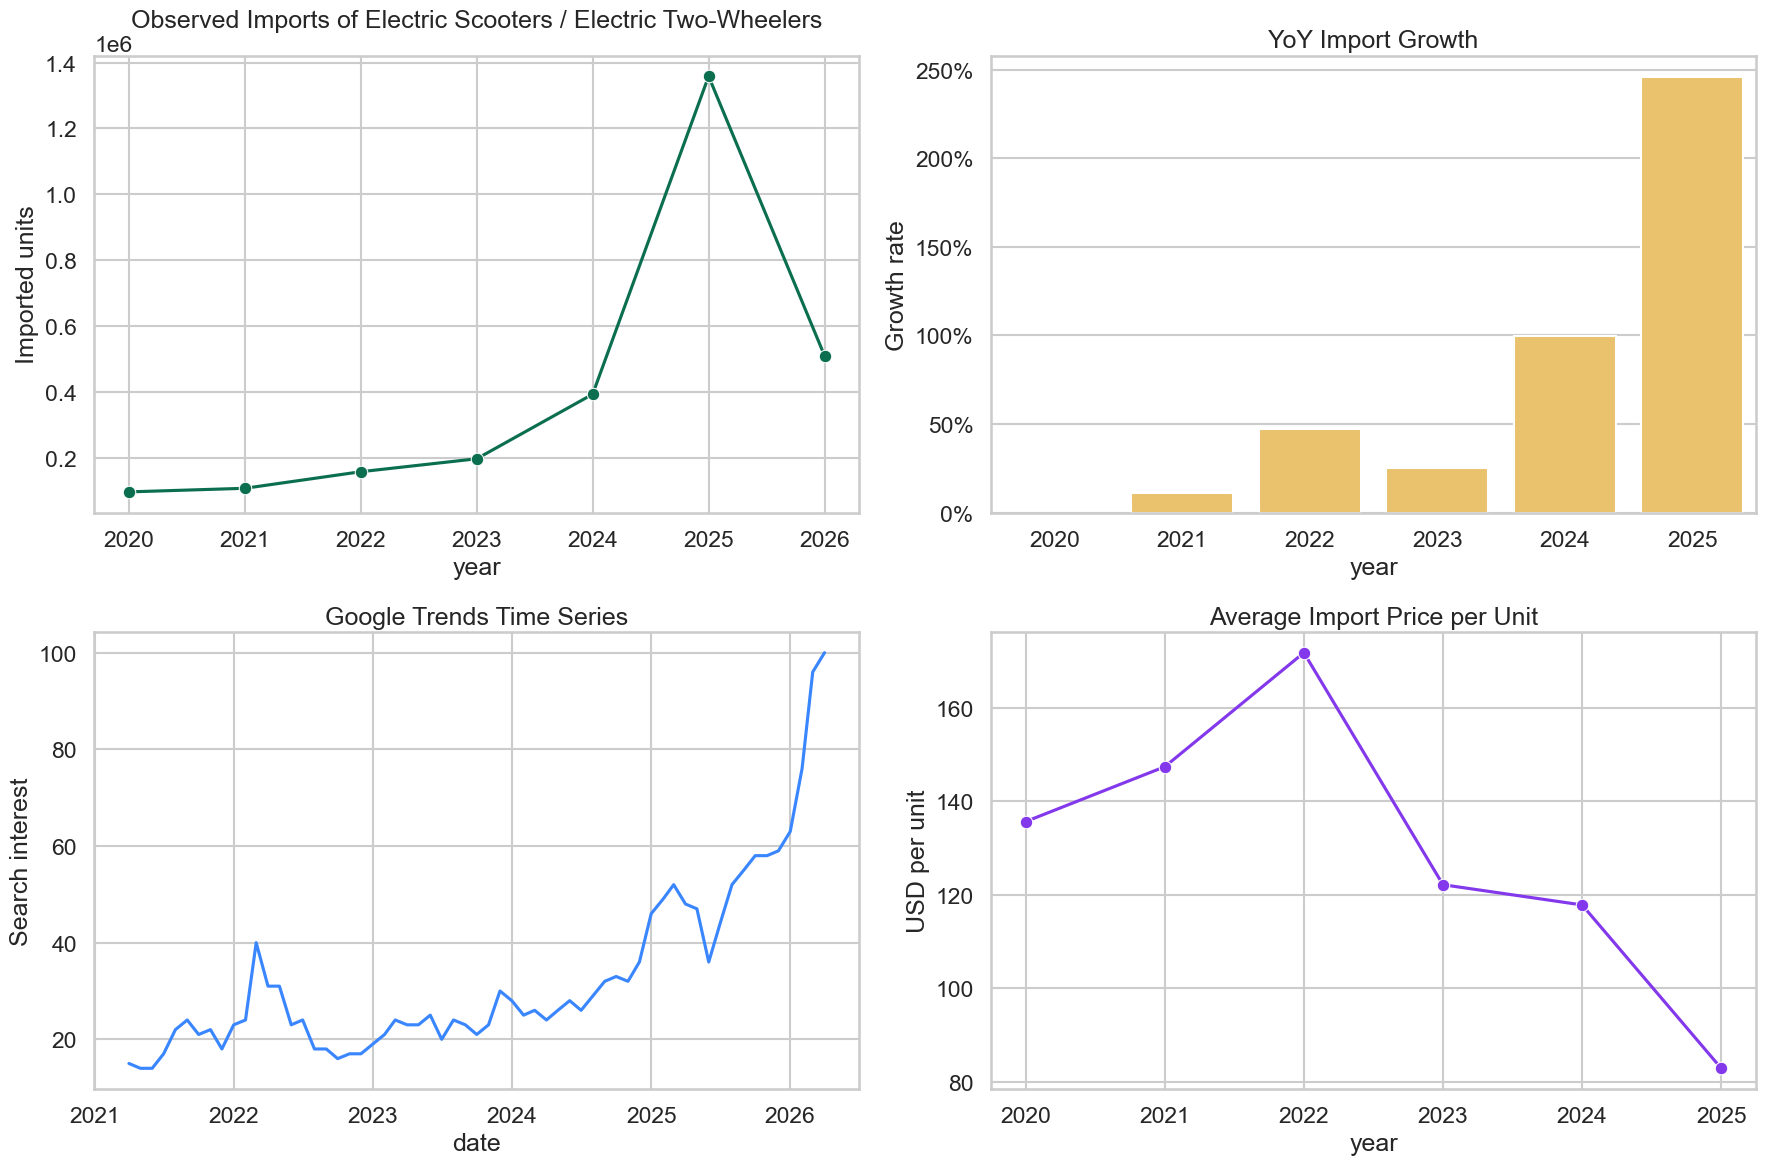

,year,imports,fob_usd,avg_price_usd,growth_pct,trends_avg
1,2021,107163,15789881,147.340,11.300,18.556
2,2022,157487,27044916,171.730,47.000,23.500
3,2023,196783,24031529,122.120,25.000,23.000
4,2024,392903,46283335,117.800,99.700,28.750
5,2025,1358284,112565133,82.870,245.700,50.333


CAGR 2020-2025: 69.80%
Price/import correlation (2020-2025): -0.823


### Top Google Queries

,query,search_interest,variation
0,moto elétrica scooter,100,-4%
1,moto,98,-10%
2,scooter moto,96,-9%
3,moto elétrica,94,-10%
4,moto scooter,94,-7%
5,moto scooter elétrica,93,-10%
6,scooter eletrica,81,-20%
7,bicicleta elétrica,47,-20%
8,bicicleta scooter elétrica,45,-20%
9,bicicleta elétrica scooter,44,-20%


### Rising Google Queries

,query,search_interest,variation
0,scooter elétrica jet 1000w,2,Breakout
1,scooter elétrica 2000w gloov,1,Breakout
2,bike scooter elétrica harley citycoco 1500w,0,Breakout
3,scooter elétrica jet,4,"1,700%"
4,scooter elétrica x12,5,850%
5,motinho elétrica,1,300%
6,scooter elétrica 1000w,20,300%
7,scooter eletrica shineray,3,300%
8,shineray eletrica,3,250%
9,scooter shineray elétrica,7,250%


In [23]:
cagr = (market_full_year["imports"].iloc[-1] / market_full_year["imports"].iloc[0]) ** (1 / (len(market_full_year) - 1)) - 1

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.lineplot(data=market_national, x="year", y="imports", marker="o", ax=axes[0, 0], color="#0B6E4F")
axes[0, 0].set_title("Observed Imports of Electric Scooters / Electric Two-Wheelers")
axes[0, 0].set_ylabel("Imported units")

sns.barplot(data=market_full_year, x="year", y="growth", ax=axes[0, 1], color="#FFC857")
axes[0, 1].set_title("YoY Import Growth")
axes[0, 1].set_ylabel("Growth rate")
axes[0, 1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

sns.lineplot(data=trends, x="date", y="trends", ax=axes[1, 0], color="#3A86FF")
axes[1, 0].set_title("Google Trends Time Series")
axes[1, 0].set_ylabel("Search interest")

sns.lineplot(data=market_full_year, x="year", y="avg_price_usd", marker="o", ax=axes[1, 1], color="#8338EC")
axes[1, 1].set_title("Average Import Price per Unit")
axes[1, 1].set_ylabel("USD per unit")

plt.tight_layout()
plt.show()

market_display = market_national.loc[market_national["year"].between(2021, 2025)].copy()
market_display["growth_pct"] = market_display["growth"].mul(100).round(1)
market_display["avg_price_usd"] = market_display["avg_price_usd"].round(2)
display(market_display[["year", "imports", "fob_usd", "avg_price_usd", "growth_pct", "trends_avg"]])

print(f"CAGR 2020-2025: {cagr:.2%}")
print(f"Price/import correlation (2020-2025): {market_full_year['avg_price_usd'].corr(market_full_year['imports']):.3f}")

display(Markdown("### Top Google Queries"))
display(top_q.head(10))
display(Markdown("### Rising Google Queries"))
display(rising_q.head(10))

## 7. Regional Analysis

**Business question: Where is growth concentrated?**

With the available data, I can only observe scooter growth at the **national** level. At the regional level, what I can identify is where **market potential** is concentrated:

- **Southeast** concentrates about **55.3% of GDP** and **38.7% of the two-wheel fleet**
- **Northeast** concentrates only **13.2% of GDP** but **27.2% of the two-wheel fleet**
- **Center-West** has the highest two-wheel fleet intensity per capita

**Business question: Is there regional inequality?**

**Answer:** Yes. The main imbalance I observe is between **purchasing power** and **mobility intensity**. The Southeast dominates in absolute economic capacity, while the Northeast and Center-West stand out in two-wheel mobility intensity.

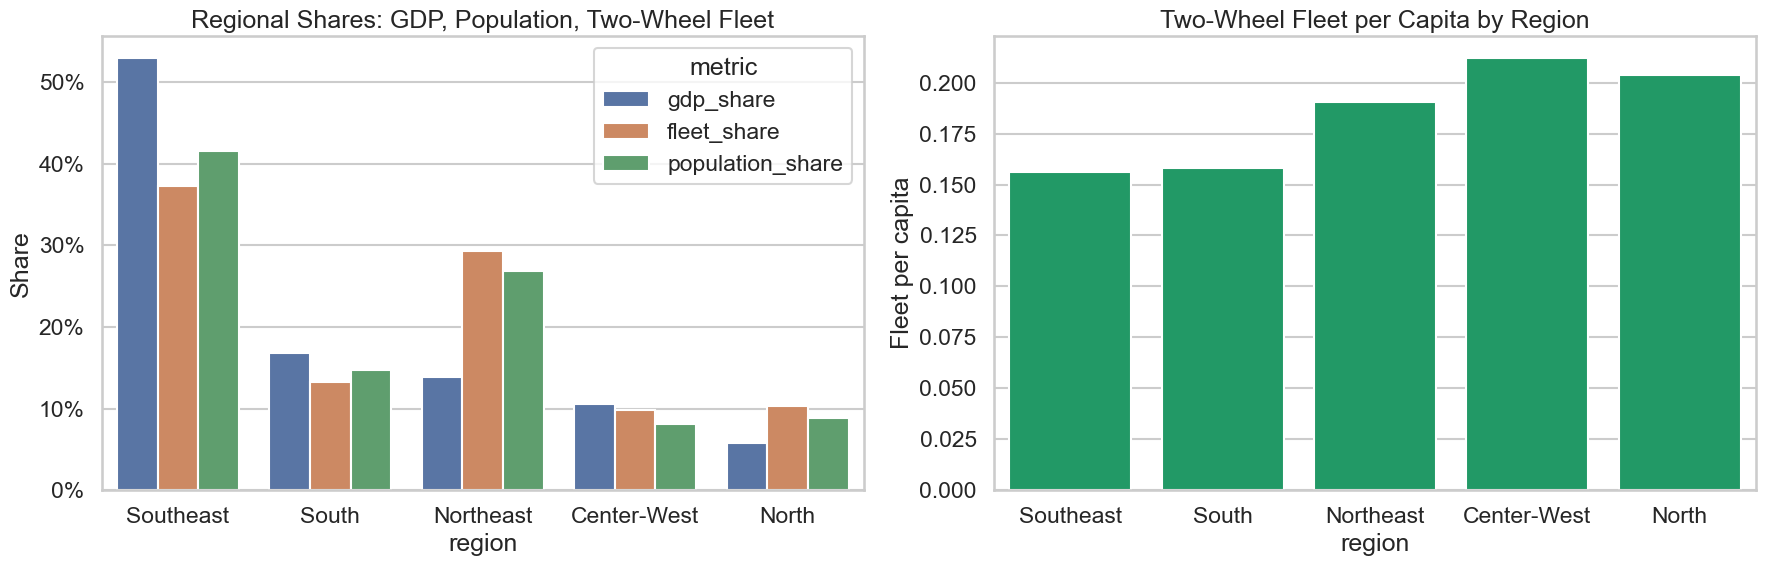

,region,gdp_2023,population,fleet_2w,gdp_share,fleet_share,population_share,gdp_pc,fleet_pc
4,Southeast,"5,799,492,759.000",88825643,13860050,0.530,0.372,0.416,65.291,0.156
3,South,"1,834,419,157.000",31310809,4954567,0.168,0.133,0.147,58.587,0.158
2,Northeast,"1,513,055,123.000",57244485,10918642,0.138,0.293,0.268,26.431,0.191
0,Center-West,"1,159,826,787.000",17238818,3657374,0.106,0.098,0.081,67.280,0.212
1,North,"636,551,611.000",18801282,3831095,0.058,0.103,0.088,33.857,0.204


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

regional_plot = regional_snapshot.sort_values("gdp_2023", ascending=False).copy()
regional_plot_melt = regional_plot.melt(
    id_vars="region",
    value_vars=["gdp_share", "fleet_share", "population_share"],
    var_name="metric",
    value_name="share",
)

sns.barplot(data=regional_plot_melt, x="region", y="share", hue="metric", ax=axes[0])
axes[0].set_title("Regional Shares: GDP, Population, Two-Wheel Fleet")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axes[0].set_ylabel("Share")

sns.barplot(data=regional_plot, x="region", y="fleet_pc", ax=axes[1], color="#0EAD69")
axes[1].set_title("Two-Wheel Fleet per Capita by Region")
axes[1].set_ylabel("Fleet per capita")

plt.tight_layout()
plt.show()

regional_snapshot.sort_values("gdp_2023", ascending=False)

## 8. Per Capita Analysis

**Business question: Which states adopt more relative to population?**

The available data does not directly measure scooter adoption by state. The closest I can get is to rank state-level readiness per capita using GDP per capita and two-wheel fleet per capita.

**Direct answer:** The strongest per-capita readiness appears in states such as **Mato Grosso**, **Mato Grosso do Sul**, **Tocantins**, **Goiás**, and **Santa Catarina**. These states combine high mobility intensity with above-average economic capacity.

**Business question: Is growth driven by mature or emerging markets?**

The evidence points to a mix:

- **Mature scale markets**: São Paulo, Minas Gerais, Rio de Janeiro, Paraná
- **Emerging high-intensity markets**: Mato Grosso, Tocantins, Goiás, Ceará, Pará

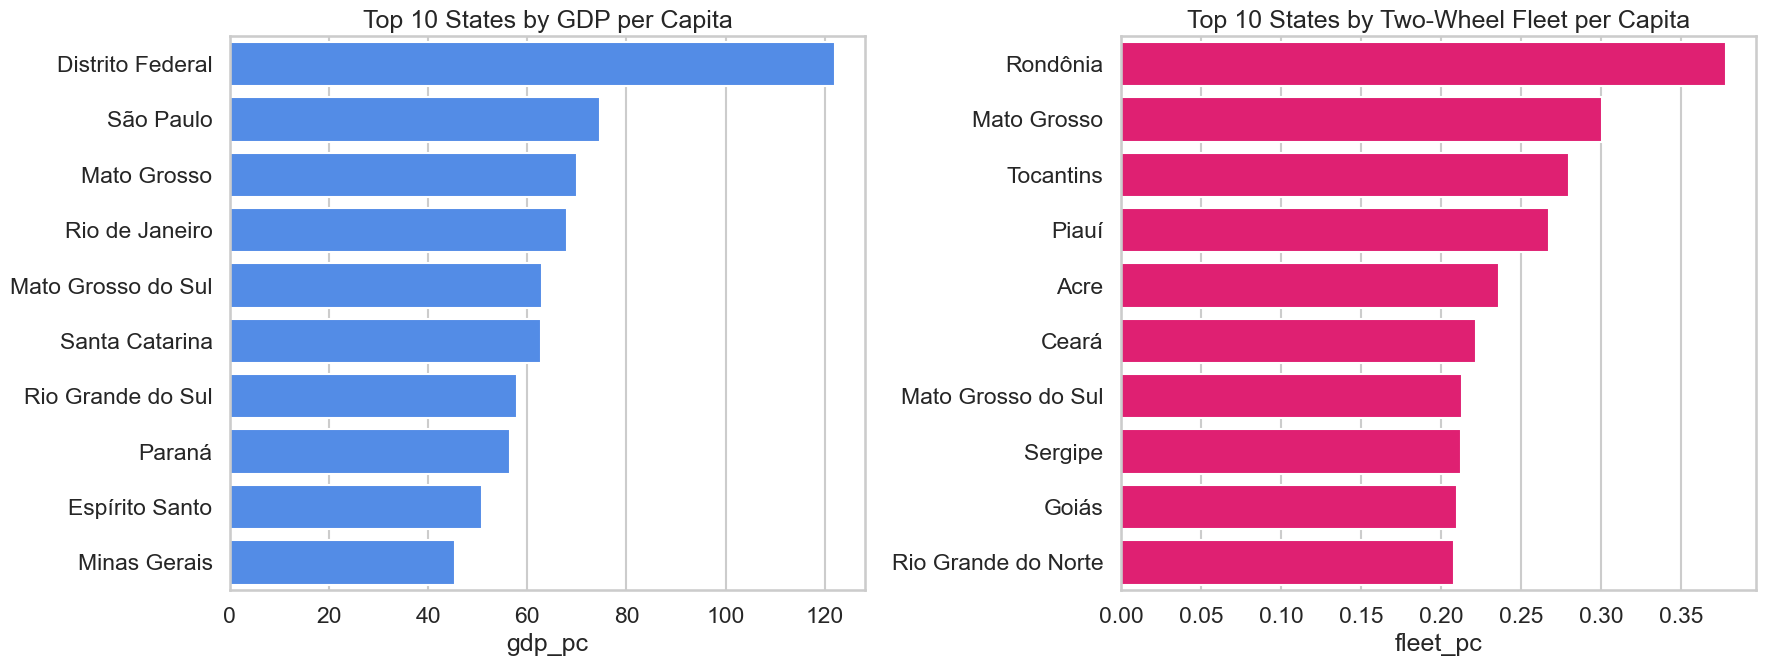

### Top states by market size proxy

,state,market_size_proxy,cons_pc
26,São Paulo,"559,586,524.009",12.143
13,Minas Gerais,"170,990,148.078",7.993
21,Rio de Janeiro,"122,781,569.127",7.129
14,Paraná,"113,015,735.377",9.505
24,Santa Catarina,"91,076,418.549",11.124
20,Rio Grande do Sul,"86,765,697.635",7.724
11,Mato Grosso,"82,034,765.878",21.069
9,Goiás,"70,678,212.666",9.521
4,Bahia,"63,607,289.839",4.277
6,Ceará,"51,474,741.396",5.554


In [25]:
top_gdp_pc = state_snapshot.sort_values("gdp_pc", ascending=False)[["state", "gdp_pc"]].head(10)
top_fleet_pc = state_snapshot.sort_values("fleet_pc", ascending=False)[["state", "fleet_pc"]].head(10)
top_market_proxy = state_snapshot.sort_values("market_size_proxy", ascending=False)[["state", "market_size_proxy", "cons_pc"]].head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=top_gdp_pc, y="state", x="gdp_pc", ax=axes[0], color="#3A86FF")
axes[0].set_title("Top 10 States by GDP per Capita")
axes[0].set_ylabel("")

sns.barplot(data=top_fleet_pc, y="state", x="fleet_pc", ax=axes[1], color="#FF006E")
axes[1].set_title("Top 10 States by Two-Wheel Fleet per Capita")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(Markdown("### Top states by market size proxy"))
display(top_market_proxy)

## 9. Correlation & Explanatory Analysis

**Business question: Does GDP explain adoption?**

For realized adoption at the state level, I can't draw a definitive conclusion because the data does not include observed scooter adoption by state. However, when looking at **market potential**, GDP is clearly a relevant factor.

**Business question: Does motorcycle fleet influence adoption?**

Again, I can't conclude this for realized state-level adoption with the current data. That said, the two-wheel fleet is a strong structural indicator of mobility readiness.

**Business question: Does digital interest correlate with real demand?**

**Answer:** Yes, at the national level. I observe a very strong same-year correlation between annual imports and the annual average of Google Trends in this dataset.

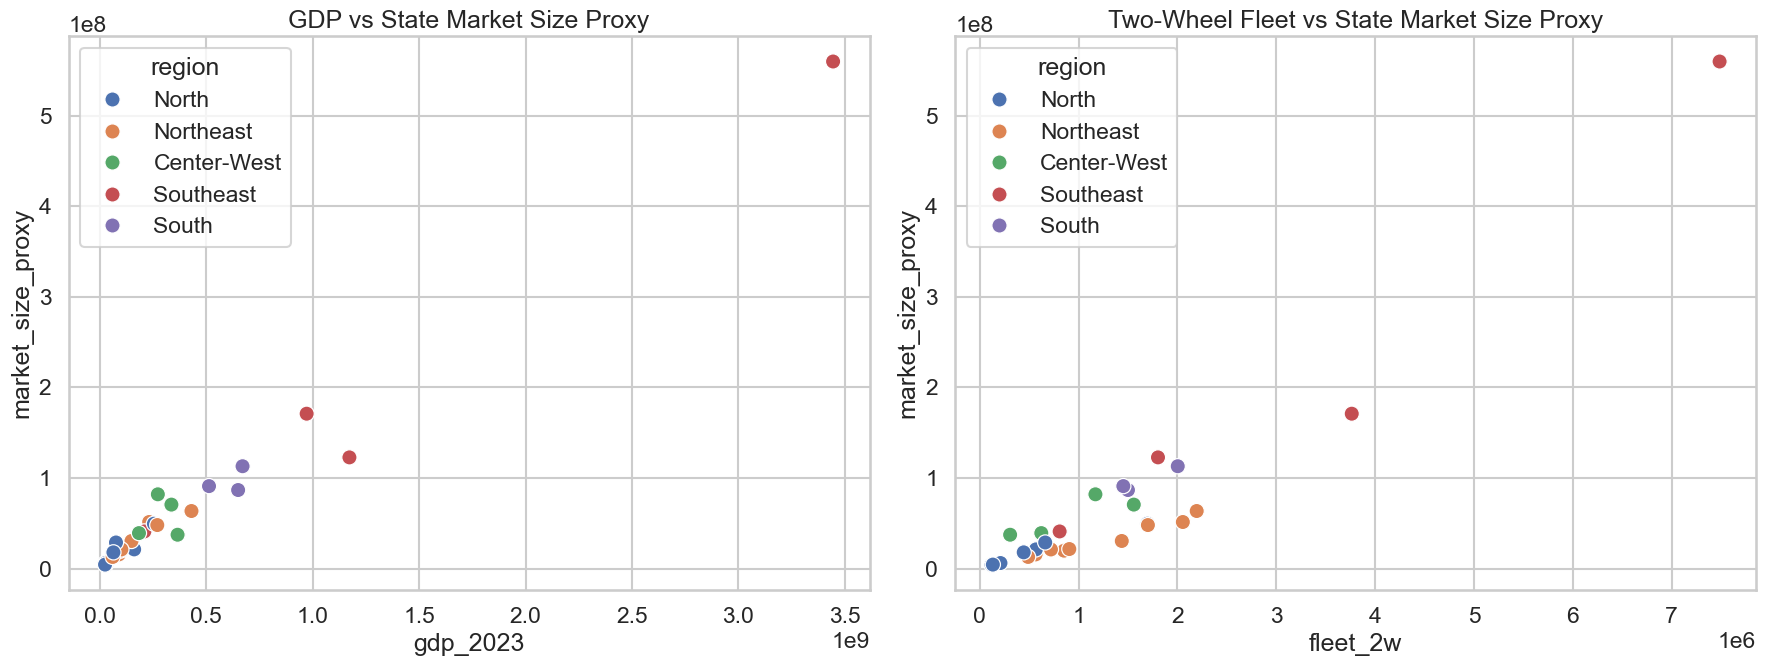

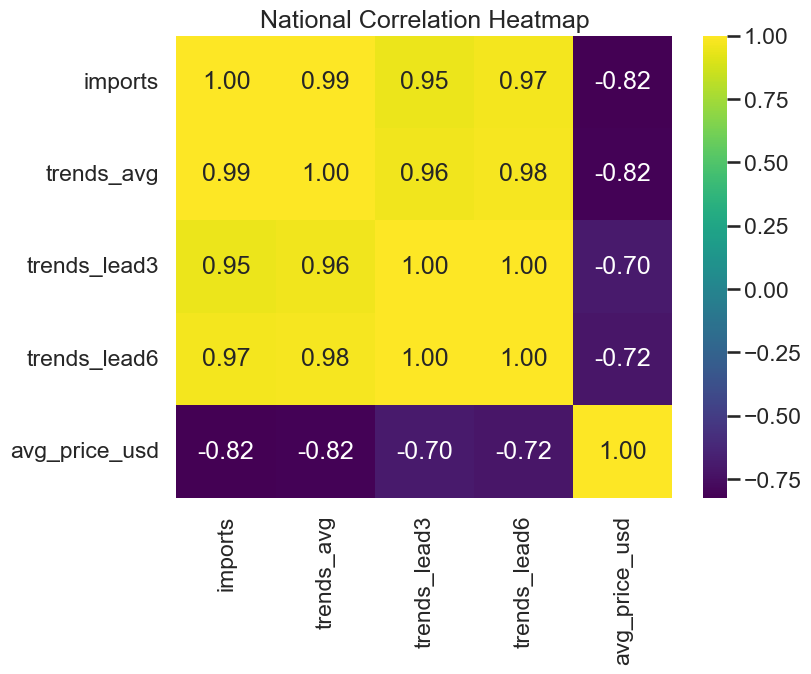

### National explanatory correlations

,feature,pearson,spearman,n_obs
0,trends_avg,0.993,0.900,5
2,trends_lead6,0.967,0.800,4
1,trends_lead3,0.946,0.800,4
3,avg_price_usd,-0.823,-0.771,6


### State opportunity correlations

,feature,pearson,spearman,n_obs
0,gdp_2023,0.987,0.955,27
2,fleet_2w,0.951,0.875,27
1,gdp_pc,0.387,0.541,27
3,fleet_pc,-0.202,-0.297,27


In [26]:
def spearman_corr(a, b):
    return pd.Series(a).rank().corr(pd.Series(b).rank(), method="pearson")


national_corr = []
for feature in ["trends_avg", "trends_lead3", "trends_lead6", "avg_price_usd"]:
    sample = market_full_year[["imports", feature]].dropna()
    national_corr.append(
        {
            "feature": feature,
            "pearson": sample["imports"].corr(sample[feature]),
            "spearman": spearman_corr(sample["imports"], sample[feature]),
            "n_obs": len(sample),
        }
    )
national_corr = pd.DataFrame(national_corr).sort_values("pearson", ascending=False)

state_corr = []
for feature in ["gdp_2023", "gdp_pc", "fleet_2w", "fleet_pc"]:
    sample = state_snapshot[[feature, "market_size_proxy"]].dropna()
    state_corr.append(
        {
            "feature": feature,
            "pearson": sample[feature].corr(sample["market_size_proxy"]),
            "spearman": spearman_corr(sample[feature], sample["market_size_proxy"]),
            "n_obs": len(sample),
        }
    )
state_corr = pd.DataFrame(state_corr).sort_values("pearson", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(data=state_snapshot, x="gdp_2023", y="market_size_proxy", hue="region", ax=axes[0], s=120)
axes[0].set_title("GDP vs State Market Size Proxy")

sns.scatterplot(data=state_snapshot, x="fleet_2w", y="market_size_proxy", hue="region", ax=axes[1], s=120)
axes[1].set_title("Two-Wheel Fleet vs State Market Size Proxy")

plt.tight_layout()
plt.show()

corr_heatmap = market_full_year[["imports", "trends_avg", "trends_lead3", "trends_lead6", "avg_price_usd"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_heatmap, annot=True, cmap="viridis", fmt=".2f")
plt.title("National Correlation Heatmap")
plt.show()

display(Markdown("### National explanatory correlations"))
display(national_corr)
display(Markdown("### State opportunity correlations"))
display(state_corr)

## 10. Temporal Analysis (Lags)

**Business question: Does digital interest precede market growth?**

The current evidence says **yes, with caution**. When annual imports are compared with the mean Google Trends level observed **3 months** and **6 months** before each year begins, the correlations remain strong.

**Answer:** The **6-month lead** is slightly stronger than the **3-month lead** in this dataset, which is directionally consistent with the idea that search behavior can anticipate future market demand.

**Methodological caveat:** This result is suggestive, not definitive, because the import target is annual and the lagged sample contains only **four comparable observations**.

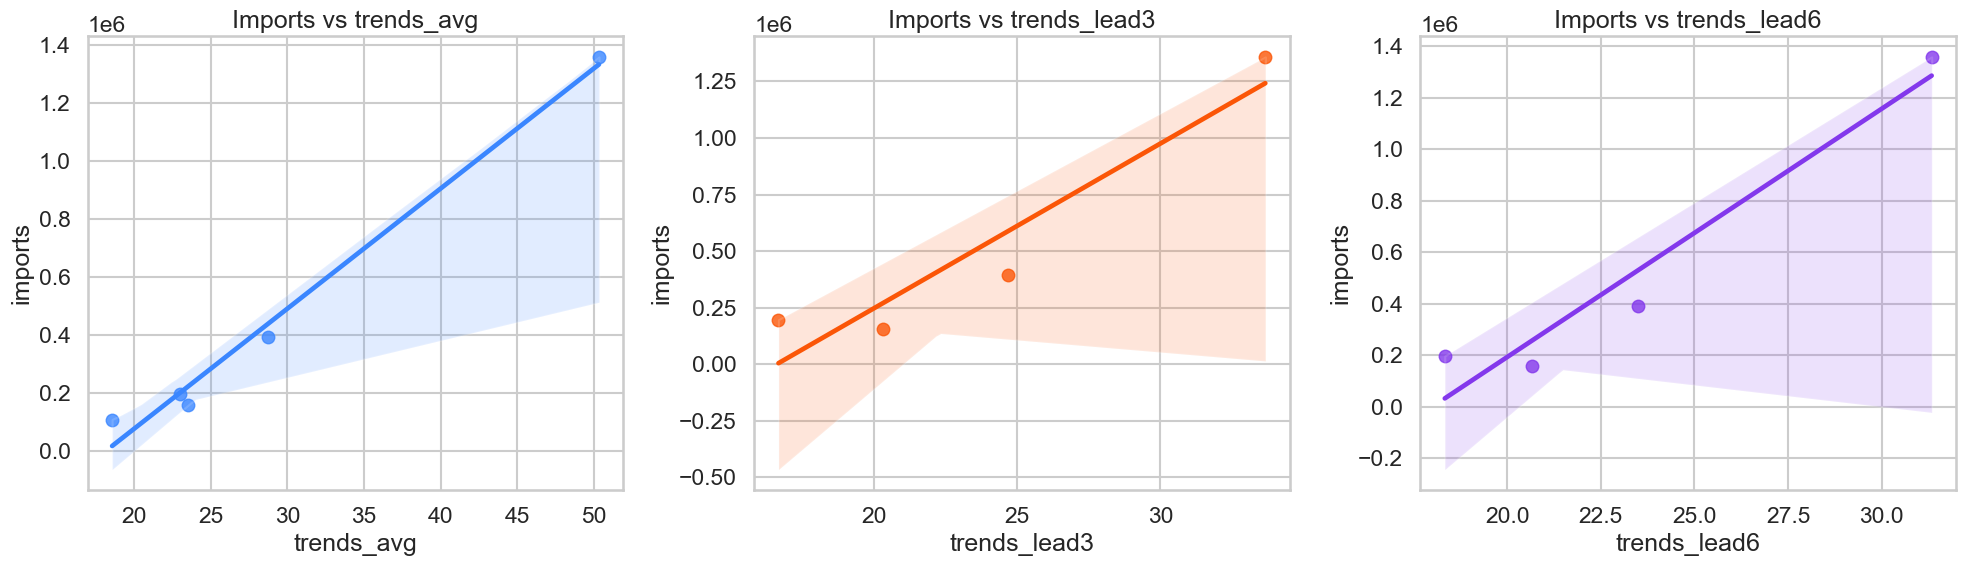

,feature,pearson,spearman,n_obs
0,trends_avg,0.993,0.900,5
2,trends_lead6,0.967,0.800,4
1,trends_lead3,0.946,0.800,4


In [27]:
lag_corr = []
for feature in ["trends_avg", "trends_lead3", "trends_lead6"]:
    sample = market_full_year[["imports", feature]].dropna()
    lag_corr.append(
        {
            "feature": feature,
            "pearson": sample["imports"].corr(sample[feature]),
            "spearman": spearman_corr(sample["imports"], sample[feature]),
            "n_obs": len(sample),
        }
    )
lag_corr = pd.DataFrame(lag_corr).sort_values("pearson", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, feature, color in zip(
    axes,
    ["trends_avg", "trends_lead3", "trends_lead6"],
    ["#3A86FF", "#FB5607", "#8338EC"],
):
    sample = market_full_year[["year", "imports", feature]].dropna()
    sns.regplot(data=sample, x=feature, y="imports", ax=ax, color=color)
    ax.set_title(f"Imports vs {feature}")
plt.tight_layout()
plt.show()

lag_corr

## 11. Clustering

The original project specification asked for clustering based on `cons_pc`, `gdp_pc`, and `trends`. Since state-level scooter consumption and state-level trends are not available, I adapted the clustering to the closest valid features:

- `gdp_pc`
- `fleet_pc`
- `market_size_proxy`

**Business question answered here:** Which types of states emerge from the data?

**Answer:** I identify three main profiles:

- **High potential**: São Paulo as a unique scale outlier
- **Consolidated**: large, wealthier markets with already strong mobility
- **Emerging**: smaller markets with meaningful two-wheel intensity and room to grow

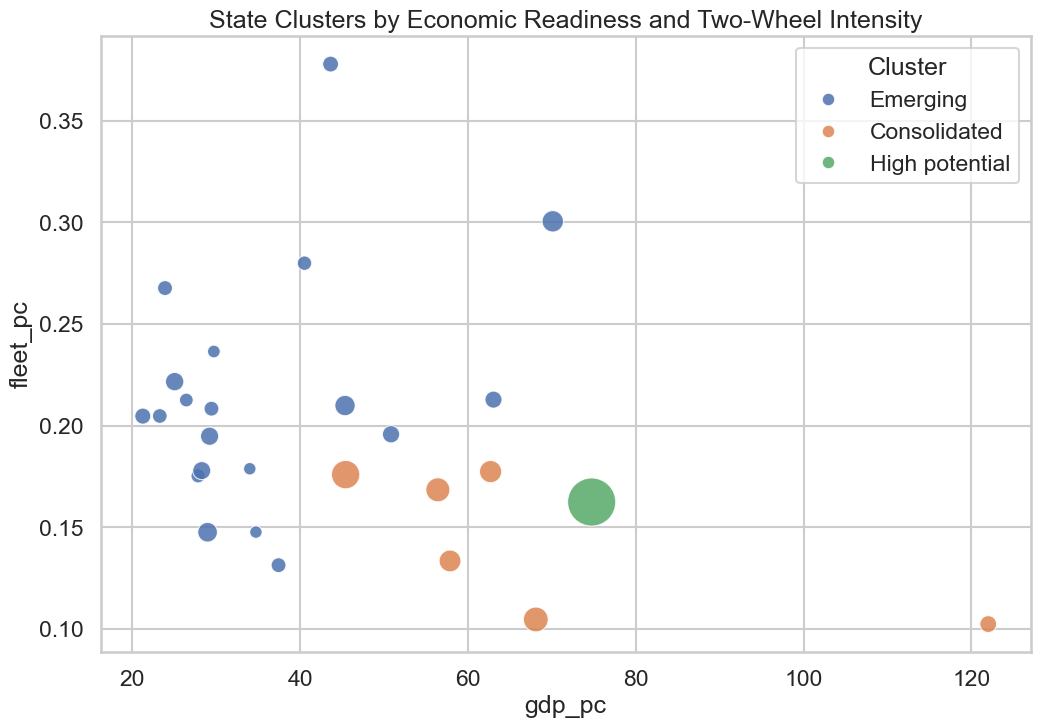

,cluster,states,avg_gdp_pc,avg_fleet_pc,avg_market_size_proxy
2,High potential,1,74.754,0.162,"559,586,524.009"
0,Consolidated,6,68.759,0.144,"103,679,635.347"
1,Emerging,20,35.660,0.214,"32,535,429.240"


### High potential

,state,region,gdp_pc,fleet_pc,market_size_proxy
26,São Paulo,Southeast,74.754,0.162,"559,586,524.009"


### Consolidated

,state,region,gdp_pc,fleet_pc,market_size_proxy
13,Minas Gerais,Southeast,45.433,0.176,"170,990,148.078"
21,Rio de Janeiro,Southeast,68.097,0.105,"122,781,569.127"
14,Paraná,South,56.425,0.168,"113,015,735.377"
24,Santa Catarina,South,62.708,0.177,"91,076,418.549"
20,Rio Grande do Sul,South,57.873,0.133,"86,765,697.635"
7,Distrito Federal,Center-West,122.016,0.102,"37,448,243.315"


### Emerging

,state,region,gdp_pc,fleet_pc,market_size_proxy
11,Mato Grosso,Center-West,70.116,0.300,"82,034,765.878"
9,Goiás,Center-West,45.362,0.210,"70,678,212.666"
4,Bahia,Northeast,28.982,0.148,"63,607,289.839"
6,Ceará,Northeast,25.056,0.222,"51,474,741.396"
16,Pará,North,29.221,0.195,"49,586,479.081"
17,Pernambuco,Northeast,28.286,0.178,"48,114,941.031"
8,Espírito Santo,Southeast,50.845,0.196,"41,072,813.978"
12,Mato Grosso do Sul,Center-West,63.051,0.213,"39,241,182.007"
10,Maranhão,Northeast,21.263,0.205,"30,545,450.423"
22,Rondônia,North,43.641,0.378,"28,886,291.738"


In [28]:
cluster_features = ["gdp_pc", "fleet_pc", "market_size_proxy"]
scaler = StandardScaler()
X = scaler.fit_transform(state_snapshot[cluster_features])

kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
state_snapshot["cluster_id"] = kmeans.fit_predict(X)

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features,
)

order = centroids.sort_values(["market_size_proxy", "gdp_pc"]).index.tolist()

cluster_labels = {
    order[0]: "Emerging",
    order[1]: "Consolidated",
    order[2]: "High potential",
}

state_snapshot["cluster"] = state_snapshot["cluster_id"].map(cluster_labels)


plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=state_snapshot,
    x="gdp_pc",
    y="fleet_pc",
    hue="cluster",
    size="market_size_proxy",
    sizes=(80, 1200),
    alpha=0.85,
)


handles, labels = ax.get_legend_handles_labels()


filtered_handles = []
filtered_labels = []

for h, l in zip(handles, labels):
    if l in state_snapshot["cluster"].unique():
        filtered_handles.append(h)
        filtered_labels.append(l)

ax.legend(filtered_handles, filtered_labels, title="Cluster")

plt.title("State Clusters by Economic Readiness and Two-Wheel Intensity")
plt.xlabel("gdp_pc")
plt.ylabel("fleet_pc")

plt.show()


cluster_summary = (
    state_snapshot.groupby("cluster", as_index=False)
    .agg(
        states=("state", "count"),
        avg_gdp_pc=("gdp_pc", "mean"),
        avg_fleet_pc=("fleet_pc", "mean"),
        avg_market_size_proxy=("market_size_proxy", "mean"),
    )
    .sort_values("avg_market_size_proxy", ascending=False)
)

display(cluster_summary)

for label in ["High potential", "Consolidated", "Emerging"]:
    display(Markdown(f"### {label}"))
    display(
        state_snapshot[state_snapshot["cluster"] == label][
            ["state", "region", "gdp_pc", "fleet_pc", "market_size_proxy"]
        ].sort_values("market_size_proxy", ascending=False).head(10)
    )

## 12. Modeling

### Mandatory regression

**Requested target:** `imports`

**Requested features:**

- `gdp_pc`
- `fleet_pc`
- `trends_lead3`

**Business question answered here:** Can I fit the requested regression model with the current data?

**Answer:** I implemented the requested specification, but the available data only yields **two aligned annual observations** once all three features are combined. That is not enough to produce a statistically meaningful model, so I explicitly report this limitation instead of presenting unreliable results.

In [29]:
gdp_brazil = gdp_long[gdp_long["state_norm"] == "BRASIL"][["year", "gdp"]].copy()
population_brazil = float(pop.loc[pop["state_norm"] == "BRASIL", "population"].iloc[0])
fleet_brazil = float(fleet.loc[fleet["state_norm"] == "BRASIL", "fleet_2w"].iloc[0])

model_df = market_national.merge(gdp_brazil, on="year", how="left")
model_df["gdp_pc"] = model_df["gdp"] / population_brazil
model_df["fleet_pc"] = fleet_brazil / population_brazil
model_df = model_df[["year", "imports", "gdp_pc", "fleet_pc", "trends_lead3"]].dropna().copy()

if len(model_df) >= 4:
    X = model_df[["gdp_pc", "fleet_pc", "trends_lead3"]]
    y = model_df["imports"]
    reg = LinearRegression().fit(X, y)
    preds = reg.predict(X)
    regression_results = pd.DataFrame(
        {
            "feature": X.columns,
            "coefficient": reg.coef_,
        }
    )
    print(f"R²: {r2_score(y, preds):.3f}")
    display(regression_results)
else:
    display(
        pd.DataFrame(
            [
                {
                    "status": "not_enough_data",
                    "aligned_observations": len(model_df),
                    "required_minimum": 4,
                    "message": "The requested regression specification is underpowered with the current source files.",
                }
            ]
        )
    )

display(Markdown("### Aligned dataset for the requested model"))
display(model_df)

,status,aligned_observations,required_minimum,message
0,not_enough_data,2,4,The requested regression specification is unde...


### Aligned dataset for the requested model

,year,imports,gdp_pc,fleet_pc,trends_lead3
2,2022,157487,47.229,0.174,20.333
3,2023,196783,51.276,0.174,16.667


## 13. Hypothesis Validation

**H1:** Google Trends increases precede market growth by 3–6 periods  
**H2:** GDP has a positive correlation with absolute adoption  
**H3:** Lower GDP states show higher relative growth  
**H4:** Motorcycle fleet is positively correlated with scooter adoption

**Business answer:** The strongest pattern I can validate with the current data is H1, but even this result should be treated as **supportive rather than definitive** due to the small lagged sample. I cannot fully validate H2, H3, and H4 in terms of observed adoption because the available data does not include a state-level scooter adoption target.

In [30]:
hypothesis_results = pd.DataFrame(
    [
        {
            "hypothesis": "H1",
            "statement": "Google Trends increases precede market growth by 3-6 periods",
            "test_used": "Annual import correlation vs lagged Google Trends",
            "evidence": "Pearson corr = 0.946 (lag 3), 0.967 (lag 6), n = 4",
            "conclusion": "Partially supported",
        },
        {
            "hypothesis": "H2",
            "statement": "GDP has a positive correlation with absolute adoption",
            "test_used": "Observed state adoption unavailable; proxy analysis only",
            "evidence": "State GDP is strongly related to market_size_proxy, but not to observed scooter adoption",
            "conclusion": "Inconclusive with current files",
        },
        {
            "hypothesis": "H3",
            "statement": "Lower GDP states show higher relative growth",
            "test_used": "Requires state-level adoption growth series",
            "evidence": "Current files do not contain state-by-year scooter adoption",
            "conclusion": "Not testable with current files",
        },
        {
            "hypothesis": "H4",
            "statement": "Motorcycle fleet is positively correlated with scooter adoption",
            "test_used": "Observed state adoption unavailable; proxy analysis only",
            "evidence": "Two-wheel fleet is strongly related to opportunity proxy, but not to observed scooter adoption",
            "conclusion": "Inconclusive with current files",
        },
    ]
)

hypothesis_results

,hypothesis,statement,test_used,evidence,conclusion
0,H1,Google Trends increases precede market growth ...,Annual import correlation vs lagged Google Trends,"Pearson corr = 0.946 (lag 3), 0.967 (lag 6), n...",Partially supported
1,H2,GDP has a positive correlation with absolute a...,Observed state adoption unavailable; proxy ana...,State GDP is strongly related to market_size_p...,Inconclusive with current files
2,H3,Lower GDP states show higher relative growth,Requires state-level adoption growth series,Current files do not contain state-by-year sco...,Not testable with current files
3,H4,Motorcycle fleet is positively correlated with...,Observed state adoption unavailable; proxy ana...,Two-wheel fleet is strongly related to opportu...,Inconclusive with current files


## 14. Final Insights

**Business question: What should I conclude from this project?**

**Answer:**

1. The electric scooter market is clearly growing in Brazil and accelerated sharply between 2024 and 2025.
2. Digital interest is the best observable leading indicator in the current dataset.
3. Falling average import price per unit is consistent with market expansion.
4. State-level opportunity is concentrated in a mix of large-scale markets and high-intensity mobility markets.
5. A stronger state-level adoption dataset would immediately elevate this analysis from opportunity mapping to true explanatory modeling.

**Current top 5 opportunity states (proxy-based):**

- São Paulo
- Mato Grosso
- Minas Gerais
- Rio de Janeiro
- Paraná

**Best opportunity lenses by region:**

- **Southeast**: scale and purchasing power
- **Center-West**: mobility intensity and mobility culture
- **Northeast**: large two-wheel base and emerging demand

**Most actionable predictive indicators:**

- rising Google Trends levels, especially with 3- to 6-month lead windows
- falling unit import price
- strong state two-wheel fleet intensity

In [31]:
state_snapshot["opportunity_score"] = (
    0.35 * ((state_snapshot["gdp_2023"] - state_snapshot["gdp_2023"].mean()) / state_snapshot["gdp_2023"].std(ddof=0))
    + 0.20 * ((state_snapshot["gdp_pc"] - state_snapshot["gdp_pc"].mean()) / state_snapshot["gdp_pc"].std(ddof=0))
    + 0.25 * ((state_snapshot["fleet_2w"] - state_snapshot["fleet_2w"].mean()) / state_snapshot["fleet_2w"].std(ddof=0))
    + 0.20 * ((state_snapshot["fleet_pc"] - state_snapshot["fleet_pc"].mean()) / state_snapshot["fleet_pc"].std(ddof=0))
)

top5_states = state_snapshot.sort_values("opportunity_score", ascending=False)[
    ["state", "region", "opportunity_score", "gdp_pc", "fleet_pc"]
].head(5)

key_drivers = pd.DataFrame(
    [
        {"driver": "Google Trends", "signal": "Strong national correlation with observed imports"},
        {"driver": "Average import price", "signal": "Negative correlation with import volume"},
        {"driver": "GDP scale", "signal": "Large states dominate absolute opportunity"},
        {"driver": "Two-wheel fleet intensity", "signal": "Strong sign of mobility readiness in emerging states"},
    ]
)

display(Markdown("### Top 5 opportunity states"))
display(top5_states)

display(Markdown("### Opportunity regions"))
display(regional_snapshot.sort_values("fleet_pc", ascending=False)[["region", "gdp_share", "fleet_share", "fleet_pc"]])

display(Markdown("### Key growth drivers"))
display(key_drivers)

### Top 5 opportunity states

,state,region,opportunity_score,gdp_pc,fleet_pc
26,São Paulo,Southeast,2.831,74.754,0.162
13,Minas Gerais,Southeast,0.653,45.433,0.176
11,Mato Grosso,Center-West,0.481,70.116,0.300
21,Rio de Janeiro,Southeast,0.382,68.097,0.105
22,Rondônia,North,0.311,43.641,0.378


### Opportunity regions

,region,gdp_share,fleet_share,fleet_pc
0,Center-West,0.106,0.098,0.212
1,North,0.058,0.103,0.204
2,Northeast,0.138,0.293,0.191
3,South,0.168,0.133,0.158
4,Southeast,0.530,0.372,0.156


### Key growth drivers

,driver,signal
0,Google Trends,Strong national correlation with observed imports
1,Average import price,Negative correlation with import volume
2,GDP scale,Large states dominate absolute opportunity
3,Two-wheel fleet intensity,Strong sign of mobility readiness in emerging ...
